In [1]:
from atomica.models import MultiClassClassifierModel, MultiLabelClassifierModel, ResidueClassifierModel
from atomica.data.dataset import MultiClassLabelledPDBDataset, LabelledPDBDataset
from atomica.trainers import Trainer

from multiclass_metrics import compute_multiclass_metrics
from multilabel_metrics import compute_multilabel_metrics

from torch.utils.data import DataLoader
import torch
from tqdm import tqdm
import numpy as np
import pandas as pd
import json
import os
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import ast
from glob import glob

MODEL_DIR = "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/"
DATA_DIR="/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_tasks"

/n/home13/afang/.conda/envs/interactenv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def get_model(model_checkpoint: str, task_name: str) -> str:
    model_config = os.path.join(os.path.dirname(model_checkpoint), "config.json")
    if task_name == "RNAGo":
        return MultiLabelClassifierModel.load_from_config_and_weights(model_config, model_checkpoint)
    elif task_name == "RNA_Ligand":
        return MultiClassClassifierModel.load_from_config_and_weights(model_config, model_checkpoint)
    elif task_name == "RNA_Protein" or task_name == "RNA_Site":
        return ResidueClassifierModel.load_from_config_and_weights(model_config, model_checkpoint)
    else:
        raise ValueError(f"Task name {task_name} not supported")

def get_atomica_results(model_checkpoint, task_name, split="val", threshold=0.5, recompute=False):
    if not recompute and os.path.exists(os.path.join(os.path.dirname(model_checkpoint), f"{split}_atomica_results.parquet")):
        results = pd.read_parquet(os.path.join(os.path.dirname(model_checkpoint), f"{split}_atomica_results.parquet"))
        if 'ckpt' in results.columns and model_checkpoint in results['ckpt'].tolist():
            return results
    dataset = MultiClassLabelledPDBDataset(f"{DATA_DIR}/{task_name}/{task_name}_{split}_processed_RNA.parquet")
    model = get_model(model_checkpoint, task_name)

    model.eval()
    model.to("cuda")
    batch_size = 1

    atomica_preds_run = []
    for i in tqdm(range(0, len(dataset), batch_size), total=len(dataset) // batch_size, desc="Running inference"):
        with torch.no_grad():
            batch = [dataset[j] for j in range(i, min(i+batch_size, len(dataset)))]
            batch = MultiClassLabelledPDBDataset.collate_fn(batch)
            batch = Trainer.to_device(batch, "cuda")
            atomica_preds_run.append(model.infer(batch).cpu().numpy())
    atomica_preds = np.concatenate(atomica_preds_run)
    
    if task_name == "RNA_Protein":
        atomica_labels = np.concatenate([x['label'] for x in dataset.data])
        atomica_ids = sum([[x['id']] * len(x['label']) for x in dataset.data], [])
        atomica_preds = atomica_preds.flatten()
    elif task_name == "RNA_Site":
        atomica_labels = np.concatenate([x['label'] for x in dataset.data])
        atomica_preds = atomica_preds.flatten()
        atomica_ids = []
        for x in dataset.data:
            assert len(x['label']) == len(x['block_to_pdb_indexes'])
            for _, pdb_index in sorted(x['block_to_pdb_indexes'].items()):
                atomica_ids.append(x['id'] + '_' + str(pdb_index))
    else:
        atomica_labels = np.array([x['label'] for x in dataset.data])
        atomica_ids = np.array([x['id'] for x in dataset.data])
        atomica_labels = list(atomica_labels)
        atomica_preds = list(atomica_preds)
    atomica_results = pd.DataFrame({
        'id': atomica_ids,
        'label': atomica_labels,
        'pred_probability': atomica_preds,
    })
    if task_name == "RNA_Ligand":
        atomica_results['pred'] = atomica_results['pred_probability'].apply(lambda x: np.argmax(x))
    elif task_name == "RNAGo":
        atomica_results['pred'] = atomica_results['pred_probability'].apply(lambda x: (x > threshold).astype(int))
    else:
        atomica_results['pred'] = (atomica_results['pred_probability'] > threshold).astype(int)

    atomica_results['ckpt'] = model_checkpoint
    atomica_results.to_parquet(os.path.join(os.path.dirname(model_checkpoint), f"{split}_atomica_results.parquet"))
    return atomica_results

In [3]:
valid_versions = []
max_epoch = 1000

files = glob(f"{MODEL_DIR}/RNA_Ligand/**/version_*/args.json")
for file in files:
    with open(file, "r") as f:
        args = json.load(f)
    if args['train_set'].endswith("_processed_RNA.parquet"):
        # if 'RNAGo' in args['train_set'] and args['run_name'] != "RNAGo_lr2e-5_final_lr2e-5_gradclip1.0_block_sampling_p_keep0.7_block_sampling_p_none0.5_weighted_lossFalse_f1_macro":
        #     continue
        # if 'RNA_Ligand' in args['train_set'] and args['run_name'] != "RNA_Ligand_lr1e-5_final_lr1e-5_gradclip1.0_block_sampling_p_keep0.9_block_sampling_p_none0.2":
        #     continue
        if not args['run_name'].endswith("_weights"):
            continue
        ckpt = args['pretrain_weights']
        version = os.path.dirname(file)
        topk_map = os.path.join(version, "checkpoint/topk_map.txt")
        with open(topk_map, "r") as f:
            for line in f.readlines():
                metric, top_ckpt = line.strip().split(": ")
                epoch = int(top_ckpt.split("epoch")[1].split("_")[0])
                if epoch < max_epoch:
                    break
        metric = float(metric)
        valid_versions.append((metric, os.path.basename(version), top_ckpt, ckpt))

valid_versions = pd.DataFrame(valid_versions, columns=["metric", "version", "top_ckpt", "pretrain_ckpt"])
valid_versions = valid_versions.sort_values(by="metric", ascending=False).reset_index(drop=True)

In [4]:
valid_versions

,metric,version,top_ckpt,pretrain_ckpt
0,0.796241,version_173,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,checkpoints/pretrain/pretrain_model_weights.pt
1,0.769976,version_171,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,checkpoints/pretrain/pretrain_model_weights.pt
2,0.755556,version_170,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,checkpoints/pretrain/pretrain_model_weights.pt
3,0.741160,version_163,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,checkpoints/pretrain/pretrain_model_weights.pt
4,0.731686,version_160,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,checkpoints/pretrain/pretrain_model_weights.pt
5,0.727391,version_161,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,checkpoints/pretrain/pretrain_model_weights.pt
6,0.688889,version_157,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,checkpoints/pretrain/pretrain_model_weights.pt
7,0.687302,version_169,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,checkpoints/pretrain/pretrain_model_weights.pt
8,0.675926,version_175,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,checkpoints/pretrain/pretrain_model_weights.pt
9,0.669109,version_164,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,checkpoints/pretrain/pretrain_model_weights.pt


In [5]:
valid_versions[valid_versions['pretrain_ckpt'] == 'checkpoints/pretrain/pretrain_model_weights.pt']["top_ckpt"].tolist()[:5]

['/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Ligand/models/version_173/checkpoint/epoch458_step18819.ckpt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Ligand/models/version_171/checkpoint/epoch794_step32595.ckpt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Ligand/models/version_170/checkpoint/epoch866_step35547.ckpt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Ligand/models/version_163/checkpoint/epoch610_step25051.ckpt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Ligand/models/version_160/checkpoint/epoch775_step31816.ckpt']

In [63]:
valid_versions[valid_versions['pretrain_ckpt'] != 'checkpoints/pretrain/pretrain_model_weights.pt']["top_ckpt"].tolist()[:5]

[]

In [6]:
all_metrics = []

for ckpt in tqdm(valid_versions["top_ckpt"].tolist(), desc="Computing metrics", total=len(valid_versions)):
    ckpt = ckpt.replace(".ckpt", ".pt")
    if not os.path.exists(ckpt):
        print(f"Checkpoint {ckpt} does not exist")
        continue
    val_results = get_atomica_results(ckpt, "RNA_Ligand", "val")
    test_results = get_atomica_results(ckpt, "RNA_Ligand", "test")

    val_metrics = compute_multiclass_metrics(
        y_true=np.stack(val_results['label']),
        y_pred=np.stack(val_results['pred']),
        y_proba=np.stack(val_results['pred_probability']),
        labels=[0,1,2]
    )

    metrics = compute_multiclass_metrics(
        y_true=np.stack(test_results['label']),
        y_pred=np.stack(test_results['pred']),
        y_proba=np.stack(test_results['pred_probability']),
        labels=[0,1,2]
    )

    all_metrics.append({
        "ckpt": ckpt,
        "val_f1_macro": val_metrics.f1_macro,
        "val_f1_micro": val_metrics.f1_micro,
        "val_f1_weighted": val_metrics.f1_weighted,
        "val_0": val_metrics.per_class[0]['f1'],
        "val_1": val_metrics.per_class[1]['f1'],
        "val_2": val_metrics.per_class[2]['f1'],
        "test_f1_macro": metrics.f1_macro,
        "test_f1_micro": metrics.f1_micro,
        "test_f1_weighted": metrics.f1_weighted,
        "test_0": metrics.per_class[0]['f1'],
        "test_1": metrics.per_class[1]['f1'],
        "test_2": metrics.per_class[2]['f1'],
    })

all_metrics = pd.DataFrame(all_metrics)

Computing metrics:   0%|          | 0/48 [00:00<?, ?it/s]/n/home13/afang/.conda/envs/interactenv/lib/python3.9/site-packages/torch/overrides.py:110: UserWarning: 'has_cuda' is deprecated, please use 'torch.backends.cuda.is_built()'
  torch.has_cuda,
/n/home13/afang/.conda/envs/interactenv/lib/python3.9/site-packages/torch/overrides.py:111: UserWarning: 'has_cudnn' is deprecated, please use 'torch.backends.cudnn.is_available()'
  torch.has_cudnn,
/n/home13/afang/.conda/envs/interactenv/lib/python3.9/site-packages/torch/overrides.py:117: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  torch.has_mps,
/n/home13/afang/.conda/envs/interactenv/lib/python3.9/site-packages/torch/overrides.py:118: UserWarning: 'has_mkldnn' is deprecated, please use 'torch.backends.mkldnn.is_available()'
  torch.has_mkldnn,
/n/home13/afang/.conda/envs/interactenv/lib/python3.9/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instanc

In [8]:
all_metrics.sort_values(by="val_f1_macro", ascending=False, inplace=True)
all_metrics['version'] = all_metrics['ckpt'].apply(lambda x: x.split("version_")[1])
all_metrics['epoch'] = all_metrics['ckpt'].apply(lambda x: int(x.split("epoch")[1].split("_")[0]))
all_metrics[all_metrics['epoch'] < 400]

,ckpt,val_f1_macro,val_f1_micro,val_f1_weighted,val_0,val_1,val_2,test_f1_macro,test_f1_micro,test_f1_weighted,test_0,test_1,test_2,version,epoch
18,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.602654,0.883721,0.840586,0.857143,0.950820,0.000000,0.473545,0.772727,0.720418,0.500000,0.920635,0.000000,132/checkpoint/epoch295_step12136.pt,295
22,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.564646,0.860465,0.821071,0.727273,0.966667,0.000000,0.473913,0.750000,0.711759,0.521739,0.900000,0.000000,131/checkpoint/epoch359_step14760.pt,359
23,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.555789,0.837209,0.806365,0.720000,0.947368,0.000000,0.546559,0.818182,0.781745,0.692308,0.947368,0.000000,130/checkpoint/epoch370_step15211.pt,370
24,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.528233,0.813953,0.774177,0.666667,0.918033,0.000000,0.531746,0.795455,0.763528,0.666667,0.928571,0.000000,129/checkpoint/epoch325_step13366.pt,325
26,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.417367,0.720930,0.655071,0.428571,0.823529,0.000000,0.365769,0.681818,0.599849,0.285714,0.811594,0.000000,147/checkpoint/epoch179_step7380.pt,179
27,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.367251,0.581395,0.566299,0.400000,0.701754,0.000000,0.361649,0.590909,0.558054,0.363636,0.721311,0.000000,146/checkpoint/epoch110_step4551.pt,110
28,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.367251,0.581395,0.566299,0.400000,0.701754,0.000000,0.386243,0.590909,0.571789,0.444444,0.714286,0.000000,150/checkpoint/epoch181_step7462.pt,181
25,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.359944,0.674419,0.602013,0.285714,0.794118,0.000000,0.435855,0.681818,0.634532,0.526316,0.781250,0.000000,154/checkpoint/epoch180_step7421.pt,180
29,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.358487,0.302326,0.227387,0.375000,0.129032,0.571429,0.128205,0.227273,0.087413,0.384615,0.000000,0.000000,145/checkpoint/epoch399_step16400.pt,399
30,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.357920,0.279070,0.186145,0.340426,0.066667,0.666667,0.424275,0.318182,0.252347,0.347826,0.125000,0.800000,152/checkpoint/epoch389_step15990.pt,389


In [72]:
all_metrics[all_metrics['epoch'] < 400]['ckpt'].tolist()[:6]

['/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Ligand/models/version_109/checkpoint/epoch383_step15744.pt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Ligand/models/version_117/checkpoint/epoch318_step13079.pt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Ligand/models/version_108/checkpoint/epoch399_step16400.pt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Ligand/models_refined/version_2/checkpoint/epoch274_step11275.pt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Ligand/models/version_118/checkpoint/epoch334_step13735.pt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Ligand/models/version_120/checkpoint/epoch371_step15252.pt']

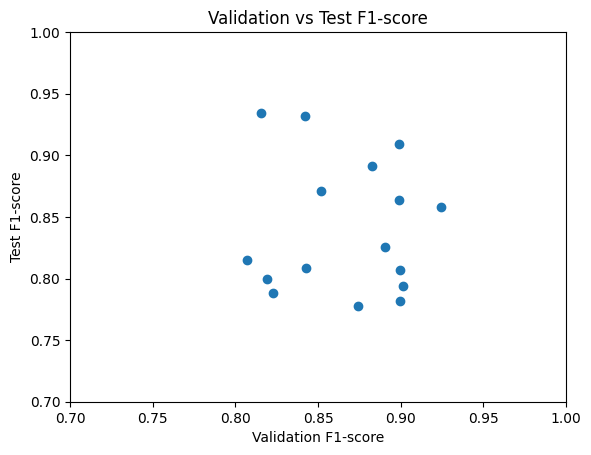

In [48]:
plt.scatter(all_metrics['val_f1_weighted'], all_metrics['test_f1_weighted'])
plt.xlim(0.7, 1)
plt.ylim(0.7, 1)
plt.xlabel("Validation F1-score")
plt.ylabel("Test F1-score")
plt.title("Validation vs Test F1-score")
plt.show()

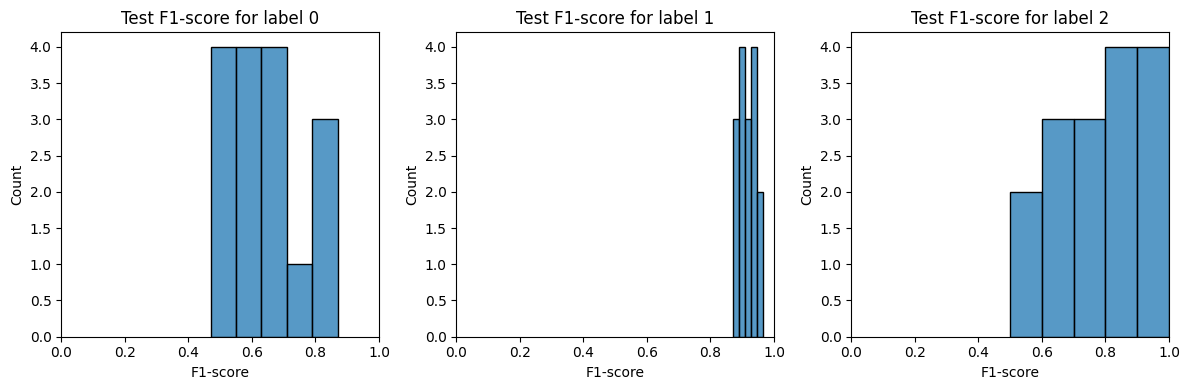

In [49]:
fig, axes = plt.subplots(1,3, figsize=(12, 4))
for i, ax in enumerate(axes):
    sns.histplot(all_metrics[f"test_{i}"], ax=ax)
    ax.set_title(f"Test F1-score for label {i}")
    ax.set_xlabel("F1-score")
    ax.set_ylabel("Count")
    ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()


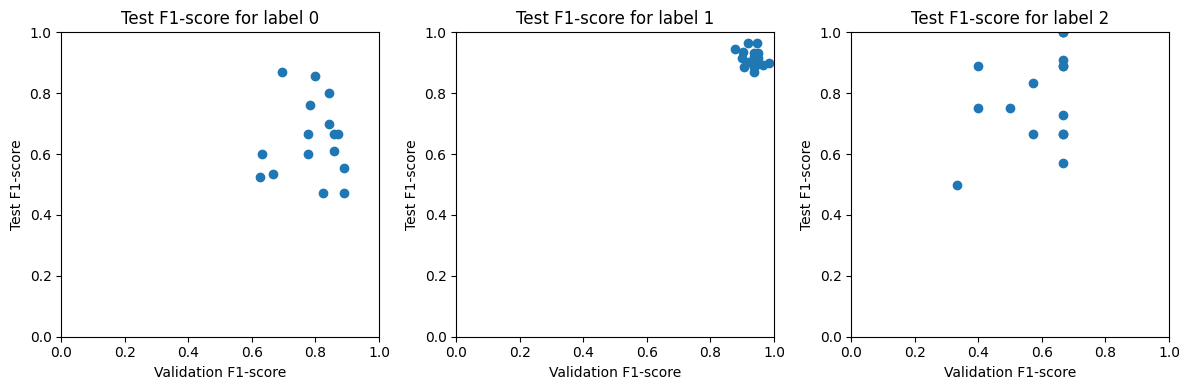

In [50]:
fig, axes = plt.subplots(1,3, figsize=(12, 4))
for i, ax in enumerate(axes):
    ax.scatter(all_metrics[f'val_{i}'], all_metrics[f'test_{i}'])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(f"Test F1-score for label {i}")
    ax.set_xlabel("Validation F1-score")
    ax.set_ylabel("Test F1-score")
plt.tight_layout()
plt.show()

In [18]:
best_ckpts = all_metrics['ckpt'].tolist()
[best_ckpts[0], best_ckpts[1], best_ckpts[3]]

['/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models/version_115/checkpoint/epoch269_step33480.pt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models/version_91/checkpoint/epoch221_step27528.pt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models/version_88/checkpoint/epoch242_step30132.pt']

In [20]:
metrics.per_label

{0: {'precision': 0.24242424242424243,
  'recall': 1.0,
  'f1': 0.3902439024390244,
  'support': 8.0,
  'jaccard': 0.24242424242424243},
 1: {'precision': 1.0,
  'recall': 1.0,
  'f1': 1.0,
  'support': 7.0,
  'jaccard': 1.0},
 2: {'precision': 0.9,
  'recall': 0.8181818181818182,
  'f1': 0.8571428571428571,
  'support': 11.0,
  'jaccard': 0.75},
 3: {'precision': 0.125,
  'recall': 1.0,
  'f1': 0.2222222222222222,
  'support': 1.0,
  'jaccard': 0.125},
 4: {'precision': 1.0,
  'recall': 0.1,
  'f1': 0.18181818181818182,
  'support': 20.0,
  'jaccard': 0.1}}